<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/class_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')


# LOAD DATA
# ============================
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Dataset/titatnic train.csv')   # or your full path
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,True,False,True,False,True
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True
5,0,28.0,0,0,8.4583,True,True,False,False,True


In [46]:
#Titanic Preprocessing Pipeline
# =============================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')

print("starting Titanic Preprocessing Pipeline...\n")

starting Titanic Preprocessing Pipeline...



In [66]:

# Cell : Data Import
# ============================
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Dataset/titatnic train.csv')   # ← Change path if needed
# data = pd.read_csv('test.csv')  # Alternative local path

print(" Data Loaded Successfully!")
print(f"Original Shape: {data.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data Loaded Successfully!
Original Shape: (891, 12)


,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,True,False,True,False,True
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True
5,0,28.0,0,0,8.4583,True,True,False,False,True


In [67]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 469 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    469 non-null    int64  
 1   Age         469 non-null    float64
 2   SibSp       469 non-null    int64  
 3   Parch       469 non-null    int64  
 4   Fare        469 non-null    float64
 5   Sex_male    469 non-null    bool   
 6   Embarked_Q  469 non-null    bool   
 7   Embarked_S  469 non-null    bool   
 8   Pclass_2    469 non-null    bool   
 9   Pclass_3    469 non-null    bool   
dtypes: bool(5), float64(2), int64(3)
memory usage: 24.3 KB


,Survived,Age,SibSp,Parch,Fare
count,469.000000,469.000000,469.000000,469.0,469.000000
mean,0.313433,30.045842,0.213220,0.0,14.846686
std,0.464384,9.805454,0.463815,0.0,11.209596
min,0.000000,5.000000,0.000000,0.0,0.000000
25%,0.000000,24.000000,0.000000,0.0,7.795800
50%,0.000000,28.000000,0.000000,0.0,9.500000
75%,1.000000,35.000000,0.000000,0.0,17.800000
max,1.000000,58.000000,2.000000,0.0,53.100000


In [68]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
Survived      0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
Pclass_2      0
Pclass_3      0
dtype: int64


In [50]:
# Confirm zero NaNs
print(df.isnull().sum().sum())   # should print 0

0


In [69]:
# Cell 3: Inject Missing Values (For learning— Optional)
# ============================

np.random.seed(42)
for col, n in {'Age':8, 'Fare':3}.items():
   data.loc[np.random.choice(data.index, n, replace=False), col] = np.nan
   # Verify
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [70]:
# ============================
# Cell 4: Data Cleaning — Missing Values
# ============================

# Fill missing values (same strategy as lecture)
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Fare'].fillna(data['Fare'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
data.drop(columns=['Cabin'], inplace=True)

print("✅ Missing Values Handled")
print(data.isnull().sum())

✅ Missing Values Handled
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [71]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (469, 10)


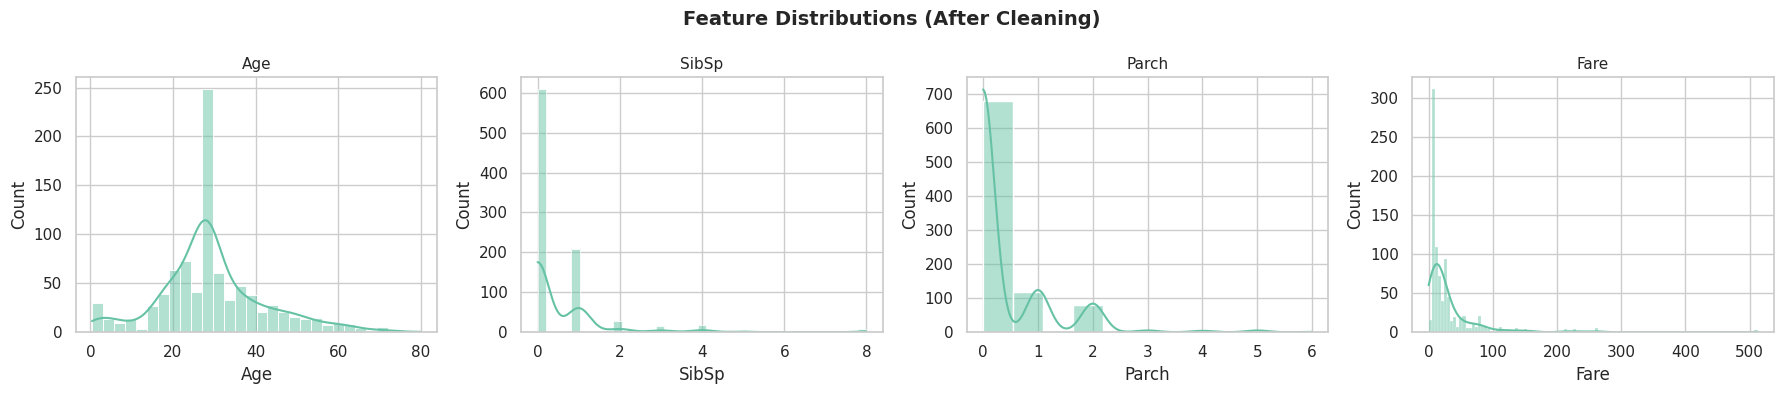

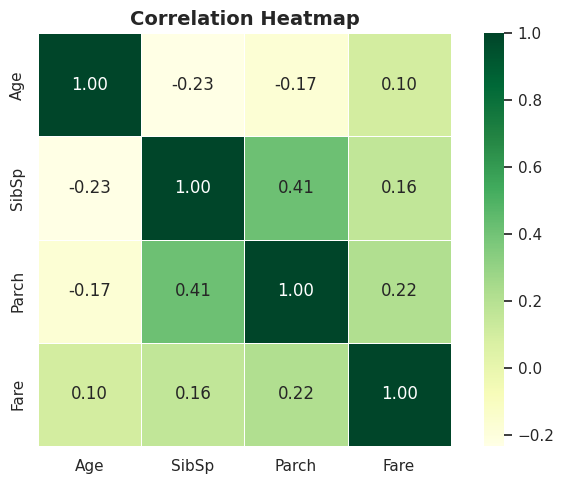

In [72]:
# ============================
# Cell 6 | Visualization — Distributions & Correlation
# ============================

# Define numeric columns (similar to lecture)
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# Plot Distributions
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data[col], ax=ax, kde=True)
    ax.set_title(col, fontsize=11)

plt.suptitle('Feature Distributions (After Cleaning)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(data[num_cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='YlGn',
            linewidths=0.5,
            square=True)
plt.title('Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()